In [2]:
import os
import numpy as np
import torch
from torch.nn.utils.rnn import pad_sequence

folder = "//experimentfs.bccn-berlin.pri/experiment/PlayNeuralData/NPX-OPTO PLAY NMM/PlayBout Analysis/play bout analysis behavior and physiology/Data/Analysis results/locomotive behaviors 2 partners"

# --- Step 1: Load .npy files ---
# Only keep files like "1410.npy" (numeric basename)
file_names = sorted(
    [
        f
        for f in os.listdir(folder)
        if f.endswith(".npy") and os.path.splitext(f)[0].isdigit()
    ]
)
sequences = []
lengths = []
valid_file_names = []

n_var_expected = 16  # must match Conv1d in_channels

for file in file_names:
    arr = np.load(os.path.join(folder, file))
    arr = np.squeeze(arr)  # drop singleton dims, e.g. (T, N, 1) -> (T, N)
    if arr.ndim != 2 or arr.shape[1] != n_var_expected:
        print(f"Skipping {file} — expected (T, {n_var_expected}), got {arr.shape}")
        continue
    tensor = torch.tensor(arr, dtype=torch.float32)  # (T_i, N)
    sequences.append(tensor)
    lengths.append(tensor.shape[0])
    valid_file_names.append(file)

if not sequences:
    raise RuntimeError("No valid .npy files found (need 2D arrays with second dim = n_var_expected).")

# --- Step 2: Pad along time: (T, N) -> (N, T) then pad dim=1 ---
sequences_transposed = [seq.transpose(0, 1) for seq in sequences]  # Each: (N, T)

# Now we pad along time (2nd dim in transposed form)
# So we want to pad along dim=1
max_time = max(lengths)
padded = []
for seq in sequences_transposed:
    # seq: (N, T_i)
    pad_len = max_time - seq.shape[1]
    if pad_len > 0:
        pad = torch.zeros((seq.shape[0], pad_len))  # (N, pad_len)
        seq_padded = torch.cat([seq, pad], dim=1)   # (N, max_time)
    else:
        seq_padded = seq
    padded.append(seq_padded)

# --- Step 3: Stack to final input tensor (B, N, T) ---
inputs = torch.stack(padded, dim=0)  # shape: (B, N, T)

# --- Step 4: Create a mask (B, T) for valid (unpadded) time steps ---
mask = torch.zeros((len(lengths), max_time), dtype=torch.float32)
for i, length in enumerate(lengths):
    mask[i, :length] = 1.0

file_names = valid_file_names  # align order with inputs / mask


Skipping 1410.npy — expected (T, 16), got (16,)
Skipping 696.npy — expected (T, 16), got (16,)
Skipping all_embeddings.npy — expected (T, 16), got (2796, 64)
Skipping cnn_filters_1.npy — expected (T, 16), got (32, 16, 5)
Skipping cnn_filters_2.npy — expected (T, 16), got (64, 32, 5)


In [3]:
print(inputs.shape)

torch.Size([2794, 16, 2617])


In [ ]:
import torch.nn as nn
import torch.optim as optim
n_var = 16;
kernel_size = 20
# --- Define the autoencoder (CNN-based) ---
class CNNAutoencoder(nn.Module):
    def __init__(self, in_channels=n_var, embedding_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=kernel_size, padding=2),
            nn.ReLU(),
            nn.Conv1d(32, embedding_dim, kernel_size=kernel_size, padding=2),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(embedding_dim, 32, kernel_size=kernel_size, padding=2),
            nn.ReLU(),
            nn.ConvTranspose1d(32, in_channels, kernel_size=kernel_size, padding=2),
        )

    def forward(self, x):
        z = self.encoder(x)   # x: (B, n_var, T)
        x_hat = self.decoder(z)
        return x_hat, z

model = CNNAutoencoder()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# --- Train the model ---
num_epochs = 1000
model.train()

for epoch in range(num_epochs):
    optimizer.zero_grad()
    x_hat, z = model(inputs)          # inputs: (B, n_var, T)
    loss = loss_fn(x_hat, inputs)     # Compare reconstructed and input
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")


Epoch 1/1000, Loss: 0.0720
Epoch 2/1000, Loss: 0.0671
Epoch 3/1000, Loss: 0.0614
Epoch 4/1000, Loss: 0.0597
Epoch 5/1000, Loss: 0.0543
Epoch 6/1000, Loss: 0.0538
Epoch 7/1000, Loss: 0.0519
Epoch 8/1000, Loss: 0.0501
Epoch 9/1000, Loss: 0.0481
Epoch 10/1000, Loss: 0.0471
Epoch 11/1000, Loss: 0.0449
Epoch 12/1000, Loss: 0.0439
Epoch 13/1000, Loss: 0.0425
Epoch 14/1000, Loss: 0.0412
Epoch 15/1000, Loss: 0.0399
Epoch 16/1000, Loss: 0.0388
Epoch 17/1000, Loss: 0.0376
Epoch 18/1000, Loss: 0.0364
Epoch 19/1000, Loss: 0.0355
Epoch 20/1000, Loss: 0.0344
Epoch 21/1000, Loss: 0.0337
Epoch 22/1000, Loss: 0.0329
Epoch 23/1000, Loss: 0.0321
Epoch 24/1000, Loss: 0.0314
Epoch 25/1000, Loss: 0.0308
Epoch 26/1000, Loss: 0.0300
Epoch 27/1000, Loss: 0.0295
Epoch 28/1000, Loss: 0.0294
Epoch 29/1000, Loss: 0.0295
Epoch 30/1000, Loss: 0.0278
Epoch 31/1000, Loss: 0.0274
Epoch 32/1000, Loss: 0.0272
Epoch 33/1000, Loss: 0.0262
Epoch 34/1000, Loss: 0.0262
Epoch 35/1000, Loss: 0.0254
Epoch 36/1000, Loss: 0.0252
E

In [5]:
# --- Save training results (run once after the training cell finishes) ---
checkpoint_path = os.path.join(folder, "training_checkpoint.pt")
autoencoder_path = os.path.join(folder, "autoencoder.pth")
data_cache_path = os.path.join(folder, "training_data.pt")

checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "final_loss": float(loss.item()),
    "num_epochs": num_epochs,
    "n_var": n_var,
    "kernel_size": kernel_size,
}
torch.save(checkpoint, checkpoint_path)
torch.save(model.state_dict(), autoencoder_path)

torch.save(
    {
        "inputs": inputs,
        "mask": mask,
        "file_names": file_names,
        "lengths": lengths,
    },
    data_cache_path,
)

print(f"Saved full checkpoint: {checkpoint_path}")
print(f"Saved model weights:  {autoencoder_path}")
print(f"Saved inputs/mask:    {data_cache_path}  (shape {tuple(inputs.shape)})")
print(f"Final loss: {checkpoint['final_loss']:.4f}")

Saved full checkpoint: //experimentfs.bccn-berlin.pri/experiment/PlayNeuralData/NPX-OPTO PLAY NMM/PlayBout Analysis/play bout analysis behavior and physiology/Data/Analysis results/locomotive behaviors 2 partners\training_checkpoint.pt
Saved model weights:  //experimentfs.bccn-berlin.pri/experiment/PlayNeuralData/NPX-OPTO PLAY NMM/PlayBout Analysis/play bout analysis behavior and physiology/Data/Analysis results/locomotive behaviors 2 partners\autoencoder.pth
Saved inputs/mask:    //experimentfs.bccn-berlin.pri/experiment/PlayNeuralData/NPX-OPTO PLAY NMM/PlayBout Analysis/play bout analysis behavior and physiology/Data/Analysis results/locomotive behaviors 2 partners\training_data.pt  (shape (2794, 16, 2617))
Final loss: 0.0038


In [6]:
# --- Load saved training (run INSTEAD of the training cell on a new session) ---
# Still run cell 0 first unless training_data.pt exists (then inputs load from cache).

import torch.nn as nn

n_var = 16
kernel_size = 20

class CNNAutoencoder(nn.Module):
    def __init__(self, in_channels=n_var, embedding_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=kernel_size, padding=2),
            nn.ReLU(),
            nn.Conv1d(32, embedding_dim, kernel_size=kernel_size, padding=2),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(embedding_dim, 32, kernel_size=kernel_size, padding=2),
            nn.ReLU(),
            nn.ConvTranspose1d(32, in_channels, kernel_size=kernel_size, padding=2),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

checkpoint_path = os.path.join(folder, "training_checkpoint.pt")
autoencoder_path = os.path.join(folder, "autoencoder.pth")
data_cache_path = os.path.join(folder, "training_data.pt")

model = CNNAutoencoder()
if os.path.isfile(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"Loaded checkpoint (epochs={ckpt['num_epochs']}, loss={ckpt['final_loss']:.4f})")
elif os.path.isfile(autoencoder_path):
    model.load_state_dict(torch.load(autoencoder_path, map_location="cpu", weights_only=False))
    print(f"Loaded weights only from {autoencoder_path}")
else:
    raise FileNotFoundError(
        f"No saved model in {folder}. Run the training cell, then the save cell above."
    )

model.eval()

if os.path.isfile(data_cache_path):
    cached = torch.load(data_cache_path, map_location="cpu", weights_only=False)
    inputs = cached["inputs"]
    mask = cached["mask"]
    file_names = cached["file_names"]
    lengths = cached["lengths"]
    print(f"Loaded cached inputs: {tuple(inputs.shape)}")
else:
    print("No training_data.pt — run cell 0 to rebuild inputs/mask/file_names.")

Loaded checkpoint (epochs=1000, loss=0.0038)
Loaded cached inputs: (2794, 16, 2617)


In [7]:
order_txt_path = os.path.join(folder, "embedding_file_order.txt")
with open(order_txt_path, "w") as f:
    for name in file_names:
        f.write(name + '/n')

torch.save(model.state_dict(), os.path.join(folder, 'autoencoder.pth'))

model.eval()
with torch.no_grad():
    # Get embeddings for all inputs
    _, embeddings = model(inputs)  # embeddings shape: (B, 64, T_padded)
    
    # Apply global average pooling across the time dimension (dim=2)
    pooled_embeddings = embeddings.mean(dim=2)  # shape: (B, 64)
    
    # Convert to NumPy array
    pooled_embeddings_np = pooled_embeddings.cpu().numpy()
    
np.save(os.path.join(folder, "all_embeddings.npy"), pooled_embeddings_np)



print(pooled_embeddings_np.shape)
print(os.path.join(folder, "all_embeddings.npy"))

(2794, 64)
//experimentfs.bccn-berlin.pri/experiment/PlayNeuralData/NPX-OPTO PLAY NMM/PlayBout Analysis/play bout analysis behavior and physiology/Data/Analysis results/locomotive behaviors 2 partners\all_embeddings.npy


In [5]:
import os
import numpy as np
import torch
from torch.nn.utils.rnn import pad_sequence
# ---------- 1. LOAD AND PAD DATA ----------
def load_and_pad_numpy_sequences(folder):
    file_names = sorted([f for f in os.listdir(folder) if f.endswith(".npy")])
    valid_tensors = []
    valid_names = []
    masks = []
    max_len = 0
    n_var_expected = 16

    for fname in file_names:
        path = os.path.join(folder, fname)
        arr = np.load(path)

        if arr.ndim != 2 or arr.shape[1] != n_var_expected:
            print(f"Skipping {fname} — unexpected shape: {arr.shape}")
            continue

        t = torch.tensor(arr, dtype=torch.float32).T  # (N, T)
        valid_tensors.append(t)
        valid_names.append(fname)
        masks.append(torch.ones(t.shape[1]))
        max_len = max(max_len, t.shape[1])

    if not valid_tensors:
        raise RuntimeError("No valid data found in folder.")

    # Pad tensors to same time length
    padded = []
    for t in valid_tensors:
        pad_len = max_len - t.shape[1]
        if pad_len > 0:
            pad = torch.zeros((t.shape[0], pad_len))
            t = torch.cat([t, pad], dim=1)
        padded.append(t)

    data = torch.stack(padded)  # (B, N, T)
    mask = torch.zeros((len(masks), max_len))
    for i, m in enumerate(masks):
        mask[i, :m.shape[0]] = 1.0

    return data, mask, valid_names


In [13]:
# ---------- 2. EXTRACT AND SAVE EMBEDDINGS ----------
import torch.nn as nn

class CNNAutoencoder(nn.Module):
    kernel_size = 20;
    def __init__(self, in_channels=16, embedding_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=kernel_size, padding=2),
            nn.ReLU(),
            nn.Conv1d(32, embedding_dim, kernel_size=kernel_size, padding=2),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(embedding_dim, 32, kernel_size=kernel_size, padding=2),
            nn.ReLU(),
            nn.ConvTranspose1d(32, in_channels, kernel_size=kernel_size, padding=2),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

def extract_and_save_embeddings(folder, data, mask, filenames):
    # Load model
    model_path = os.path.join(folder, 'autoencoder.pth')
    model = CNNAutoencoder()
    model.load_state_dict(torch.load(model_path, map_location='cpu'))
    model.eval()

    with torch.no_grad():
        data = data  # (B, N, T)
        mask = mask.unsqueeze(1)  # (B, 1, T)

        z = model.encoder(data)  # (B, 64, T)
        masked_z = z * mask
        sum_z = masked_z.sum(dim=2)       # (B, 64)
        lengths = mask.sum(dim=2)         # (B, 1)
        avg_z = sum_z / lengths           # (B, 64)

    np.save(os.path.join(folder, 'embeddings.npy'), avg_z.numpy())
    with open(os.path.join(folder, 'file_order.txt'), 'w') as f:
        for fname in filenames:
            f.write(f"{fname}\n")


In [ ]:
print('load and saved')

In [7]:
second_folder = r'//experimentfs.bccn-berlin.pri/experiment/PlayNeuralData/NPX-OPTO PLAY NMM/PlayBout Analysis/play bout analysis behavior and physiology/Data/Analysis results/non labeled behavior 2 partners'

# Load once
data, mask, filenames = load_and_pad_numpy_sequences(second_folder)
print('ready')

ready


In [14]:

# Later: estimate embeddings
extract_and_save_embeddings(second_folder, data, mask, filenames)
print('ready')

C:\Users\miguel\AppData\Local\Temp\ipykernel_83572\3463138951.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=

ready


In [8]:
import os
import torch
import numpy as np

# Assume CNNAutoencoder class is already defined exactly as in your training code
model = CNNAutoencoder()

# Load the saved weights
model_path = os.path.join(second_folder, 'autoencoder.pth')
model.load_state_dict(torch.load(model_path, map_location='cpu'))
model.eval()

# Extract filters from the first Conv1d layer of encoder
# This will be a tensor of shape [out_channels, in_channels, kernel_size]
filters_tensor_1 = model.encoder[0].weight.data.cpu()
filters_tensor_2 = model.encoder[2].weight.data.cpu()

# Convert to numpy array
filters_np_1 = filters_tensor_1.numpy()
filters_np_2 = filters_tensor_2.numpy()

# Save to numpy file
filters_save_path = os.path.join(folder, 'cnn_filters_1.npy')
np.save(filters_save_path, filters_np_1)

filters_save_path = os.path.join(folder, 'cnn_filters_2.npy')
np.save(filters_save_path, filters_np_2)

print(f"Saved filters numpy array of shape {filters_np.shape} to {filters_save_path}")


NameError: name 'second_folder' is not defined

Loaded embeddings from: //experimentfs.bccn-berlin.pri/experiment/PlayNeuralData/NPX-OPTO PLAY NMM/PlayBout Analysis/play bout analysis behavior and physiology/Data/Analysis results/locomotive behaviors 2 partners\all_embeddings.npy
Embeddings shape: (2794, 64)


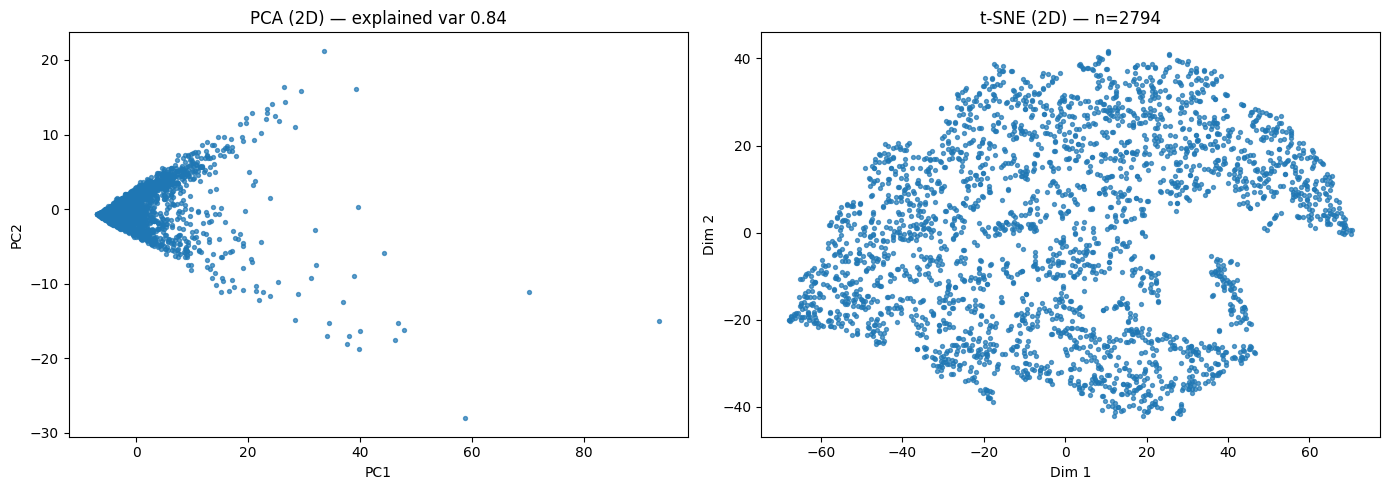

In [2]:
# --- Visualize embeddings: do they cluster? ---
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

folder = "//experimentfs.bccn-berlin.pri/experiment/PlayNeuralData/NPX-OPTO PLAY NMM/PlayBout Analysis/play bout analysis behavior and physiology/Data/Analysis results/locomotive behaviors 2 partners"  # change this!

# Load embeddings (prefer variable from above if present)
if "pooled_embeddings_np" in globals():
    E = pooled_embeddings_np
    src = "in-memory pooled_embeddings_np"
else:
    emb_path1 = os.path.join(folder, "all_embeddings.npy")
    emb_path2 = os.path.join(folder, "embeddings.npy")
    if os.path.isfile(emb_path1):
        E = np.load(emb_path1)
        src = emb_path1
    elif os.path.isfile(emb_path2):
        E = np.load(emb_path2)
        src = emb_path2
    else:
        raise FileNotFoundError(
            f"Could not find embeddings at {emb_path1} or {emb_path2}. Run the embedding cell first."
        )

print(f"Loaded embeddings from: {src}")
print("Embeddings shape:", E.shape)

# Optional coloring by filename prefix (if available)
labels = None
if "file_names" in globals() and len(file_names) == E.shape[0]:
    # Use digits prefix if present, otherwise take text before first '_' as group
    def group_name(fn: str) -> str:
        base = os.path.splitext(os.path.basename(fn))[0]
        if base and base.split("_")[0].isdigit():
            return base.split("_")[0]
        return base.split("_")[0]

    labels = np.array([group_name(f) for f in file_names])

# Standardize before PCA/t-SNE
E_std = StandardScaler().fit_transform(E)

# PCA 2D
pca = PCA(n_components=2, random_state=0)
E_pca = pca.fit_transform(E_std)

# t-SNE 2D (can be slow; downsample if huge)
max_points = 3000
idx = np.arange(E_std.shape[0])
if E_std.shape[0] > max_points:
    rng = np.random.default_rng(0)
    idx = rng.choice(E_std.shape[0], size=max_points, replace=False)

tsne = TSNE(
    n_components=2,
    perplexity=min(30, max(5, (len(idx) - 1) // 3)),
    init="pca",
    learning_rate="auto",
    random_state=0,
)
E_tsne = tsne.fit_transform(E_std[idx])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot PCA
ax = axes[0]
if labels is None:
    ax.scatter(E_pca[:, 0], E_pca[:, 1], s=8, alpha=0.7)
else:
    uniq = np.unique(labels)
    for u in uniq[:30]:  # avoid unreadable legends if too many groups
        m = labels == u
        ax.scatter(E_pca[m, 0], E_pca[m, 1], s=10, alpha=0.7, label=str(u))
    if len(uniq) <= 30:
        ax.legend(markerscale=2, fontsize=8, loc="best")
ax.set_title(f"PCA (2D) — explained var {pca.explained_variance_ratio_.sum():.2f}")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")

# Plot t-SNE
ax = axes[1]
if labels is None:
    ax.scatter(E_tsne[:, 0], E_tsne[:, 1], s=8, alpha=0.7)
else:
    labels_sub = labels[idx]
    uniq = np.unique(labels_sub)
    for u in uniq[:30]:
        m = labels_sub == u
        ax.scatter(E_tsne[m, 0], E_tsne[m, 1], s=10, alpha=0.7, label=str(u))
    if len(uniq) <= 30:
        ax.legend(markerscale=2, fontsize=8, loc="best")
ax.set_title(f"t-SNE (2D) — n={len(idx)}")
ax.set_xlabel("Dim 1")
ax.set_ylabel("Dim 2")

plt.tight_layout()
plt.show()